In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [7]:
def load_temporal_log(json_path):
    with open(json_path, "r") as f:
        log = json.load(f)

    rows = []
    for step_entry in log.get("steps", []):
        step = step_entry["step"]
        windows = step_entry.get("windows_used", [])
        for epoch_entry in step_entry.get("epochs", []):
            rows.append({
                "model": log.get("model", "unknown"),
                "run_timestamp": log.get("timestamp", "unknown"),
                "step": step,
                "epoch": epoch_entry["epoch"],
                "train_loss": epoch_entry["train_loss"],
                "train_acc": epoch_entry["train_acc"],
                "val_past_acc": epoch_entry["val_past_acc"],
                "val_next_acc": epoch_entry["val_next_acc"],
                "val_all_acc": epoch_entry["val_all_acc"],
                #######################
                "val_past_prec": epoch_entry["val_past_prec"],
                "val_next_prec": epoch_entry["val_next_prec"],
                "val_all_prec": epoch_entry["val_all_prec"],
                #######################
                "val_past_recall": epoch_entry["val_past_recall"],
                "val_next_recall": epoch_entry["val_next_recall"],
                "val_all_recall": epoch_entry["val_all_recall"],
                #######################
                "val_past_f1": epoch_entry["val_past_f1"],
                "val_next_f1": epoch_entry["val_next_f1"],
                "val_all_f1": epoch_entry["val_all_f1"],
                #######################
                "val_past_seenf1": epoch_entry["val_past_seenf1"],
                "val_next_seenf1": epoch_entry["val_next_seenf1"],
                "val_all_seenf1": epoch_entry["val_all_seenf1"],
                #######################
                "val_past_unseenf1": epoch_entry["val_past_unseenf1"],
                "val_next_unseenf1": epoch_entry["val_next_unseenf1"],
                "val_all_unseenf1": epoch_entry["val_all_unseenf1"],
                #######################
                "val_past_aroc": epoch_entry["val_past_aroc"],
                "val_next_aroc": epoch_entry["val_next_aroc"],
                "val_all_aroc": epoch_entry["val_all_aroc"],
                "epoch_minutes": epoch_entry["epoch_minutes"],
            })

    df = pd.DataFrame(rows)

    # Clean NaNs
    df = df.replace([np.nan, float("nan")], 0.0)

    return df

def load_multiple_logs(json_paths):
    dfs = []
    for path in json_paths:
        df = load_temporal_log(path)
        df["run_name"] = Path(path).stem  # file name
        dfs.append(df)
    return dfs

def validate_logs(dfs):
    meta = [(df["step"].nunique(), df["epoch"].nunique()) for df in dfs]
    first_steps, first_epochs = meta[0]

    for i, (steps, epochs) in enumerate(meta):
        if steps != first_steps:
            raise ValueError(f"Log {i} has {steps} steps, expected {first_steps}.")
        if epochs != first_epochs:
            raise ValueError(f"Log {i} has {epochs} epochs per step, expected {first_epochs}.")

    print("All logs validated: identical steps & epochs.")

def plot_metric_comparison(dfs, metric, save=False):
    plt.figure(figsize=(8, 5))
    
    for df in dfs:
        run_label = df["run_name"].iloc[0]
        grouped = df.groupby("step")[metric].mean()
        plt.plot(grouped.index, grouped.values, marker="o", label=run_label)

    plt.title(f"Comparison: {metric}")
    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)

    if save:
        plt.savefig(f"{metric}_comparison.png", dpi=300)

    plt.show()

def compare_logs(json_files):
    dfs = load_multiple_logs(json_files)
    validate_logs(dfs)

    metrics = [
        "train_loss",
        "train_acc",
        "val_past_acc",
        "val_next_acc",
        "val_all_acc",
        #######################
        "val_past_prec",
        "val_next_prec",
        "val_all_prec",
        #######################
        "val_past_recall",
        "val_next_recall",
        "val_all_recall",
        #######################
        "val_past_f1",
        "val_next_f1",
        "val_all_f1",
        #######################
        "val_past_seenf1",
        "val_next_seenf1",
        "val_all_seenf1",
        #######################
        "val_past_unseenf1",
        "val_next_unseenf1",
        "val_all_unseenf1",
        #######################
        "val_past_aroc",
        "val_next_aroc",
        "val_all_aroc"
    ]

    for metric in metrics:
        plot_metric_comparison(dfs, metric, save=True)

    return dfs

In [18]:
def plot_clean(dfs, custom_names=None, save=True, metric = "val_next_f1"):
    """
    Plot optional custom model labels.
    custom_names should be a dict: { run_name : display_name }
    """

    plt.figure(figsize=(6, 4))

    # Academic style
    plt.rc("font", family="serif")
    plt.grid(True, linestyle="--", alpha=0.4)

    for df in dfs:
        run_key = df["run_name"].iloc[0]

        # Use custom label if provided
        if custom_names and run_key in custom_names:
            label = custom_names[run_key]
        else:
            label = run_key   # fallback

        # Average across epochs within each step
        grouped = df.groupby("step")[metric].mean()

        plt.plot(
            grouped.index,
            grouped.values,
            marker="o",
            linewidth=2.2,
            markersize=4,
            label=label
        )

    plt.xlabel("Window Step", fontsize=12)
    plt.ylabel("Next-Window F1 Score", fontsize=12)
    plt.title("Comparison of Temporal Next-Window F1", fontsize=14)
    plt.legend(fontsize=8)
    plt.tight_layout()

    if save:
        Path("plots").mkdir(exist_ok=True)
        plt.savefig(f"plots/{metric}_clean.png", dpi=400, bbox_inches="tight")

    plt.show()

def load_multiple_logs(json_paths):
    dfs = []
    for path in json_paths:
        df = load_temporal_log(path)
        df["run_name"] = Path(path).stem
        dfs.append(df)
    return dfs

In [8]:
json_files = [
    "training/logs/full_metrics/NEW_nonzero_Temporal_ResNet50+FFT_run_20251202_020614.json", # resnet50+fft with setting fft weights to 0
    "training/logs/full_metrics/NEW_NoJpeg_0d_Temporal_ResNet50+FFT_run_20251205_112840.json", # resnet50+fft  with seeing fft weights to 0 with no jpg augmentation
    "training/logs/full_metrics/NEW_Temporal_ResNet50_run_20251201_173932.json", # resnet50 normal
    "training/logs/full_metrics/NEW_Temporal_NoJpeg_ResNet50_run_20251204_180922.json", # resnet50 normal with no jpeg
]

In [9]:
no_jpeg_resnet = load_temporal_log(json_files[1])
no_jpeg_resnet

,model,run_timestamp,step,epoch,train_loss,train_acc,val_past_acc,val_next_acc,val_all_acc,val_past_prec,...,val_past_seenf1,val_next_seenf1,val_all_seenf1,val_past_unseenf1,val_next_unseenf1,val_all_unseenf1,val_past_aroc,val_next_aroc,val_all_aroc,epoch_minutes
0,NEW_NoJpeg_0d_Temporal_ResNet50+FFT,20251205_112840,0,1,0.221929,98.855606,98.523703,96.525929,79.943543,94.238895,...,98.622047,0.0,98.588776,0.0,86.843034,87.319986,0.997977,0.967938,0.887148,17.833701
1,NEW_NoJpeg_0d_Temporal_ResNet50+FFT,20251205_112840,1,1,0.241735,97.705165,97.915584,96.769466,81.277347,96.829904,...,96.533596,0.0,96.889325,0.0,86.564942,86.901670,0.994775,0.983121,0.891485,18.980155
2,NEW_NoJpeg_0d_Temporal_ResNet50+FFT,20251205_112840,2,1,0.244323,97.546802,97.972722,97.452351,83.630910,97.676183,...,97.251539,0.0,97.206335,0.0,90.972222,91.387063,0.996369,0.969620,0.904834,23.239556
3,NEW_NoJpeg_0d_Temporal_ResNet50+FFT,20251205_112840,3,1,0.253835,97.026589,96.977416,97.228916,85.892731,96.036287,...,98.421738,0.0,98.471296,0.0,99.434318,99.339415,0.993690,0.997607,0.919514,28.218189
4,NEW_NoJpeg_0d_Temporal_ResNet50+FFT,20251205_112840,4,1,0.247381,97.378674,97.251624,96.244608,87.145378,96.859723,...,98.433048,0.0,98.347482,0.0,93.056021,93.377926,0.994395,0.978384,0.925115,21.717632
5,NEW_NoJpeg_0d_Temporal_ResNet50+FFT,20251205_112840,5,1,0.250887,97.190157,97.191511,95.060080,86.997177,97.001661,...,98.477758,0.0,98.505055,0.0,86.370262,86.411658,0.994701,0.940615,0.924236,22.406626
6,NEW_NoJpeg_0d_Temporal_ResNet50+FFT,20251205_112840,6,1,0.266987,96.346015,94.583962,87.097798,89.523641,94.360092,...,98.382774,0.0,98.359292,0.0,53.327172,52.165813,0.989258,0.787992,0.953453,23.669187
7,NEW_NoJpeg_0d_Temporal_ResNet50+FFT,20251205_112840,7,1,0.311647,93.312550,91.799051,87.421463,89.848271,91.758256,...,96.610657,0.0,96.589415,0.0,74.346793,73.040000,0.974753,0.836977,0.958761,25.533076


All logs validated: identical steps & epochs.


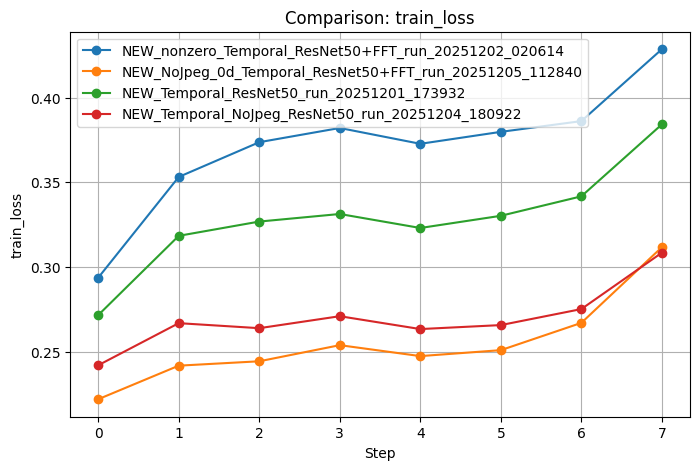

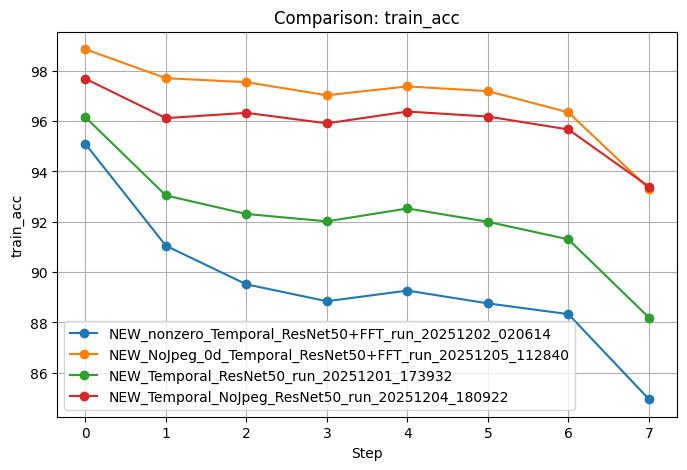

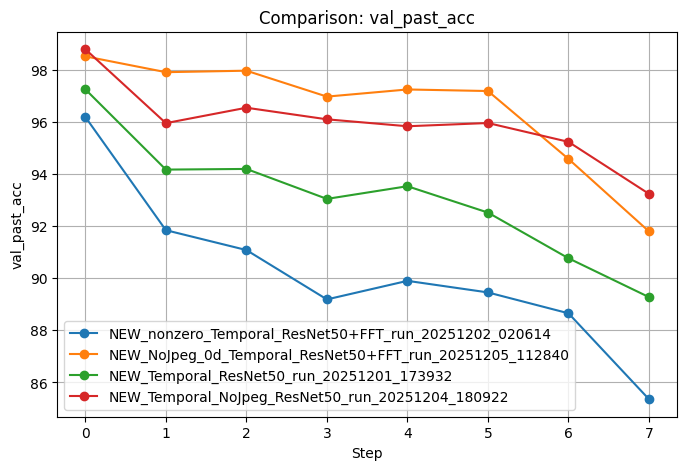

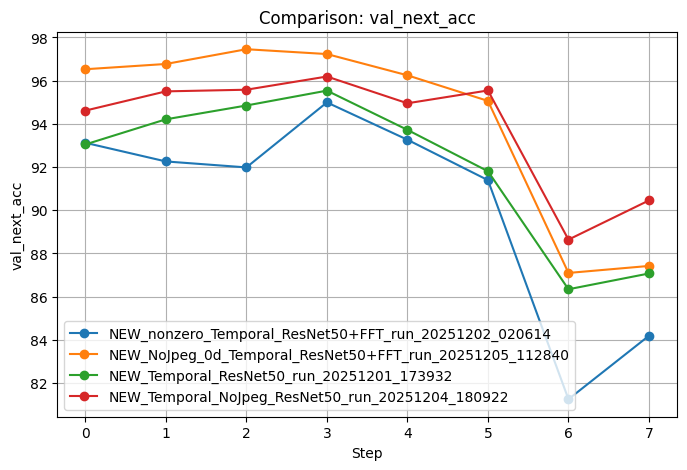

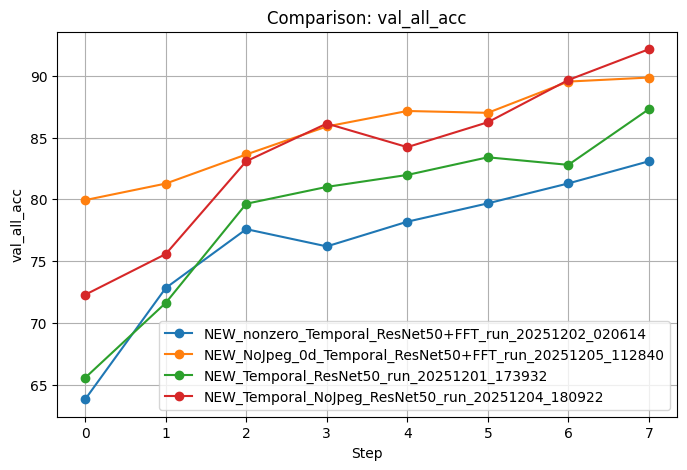

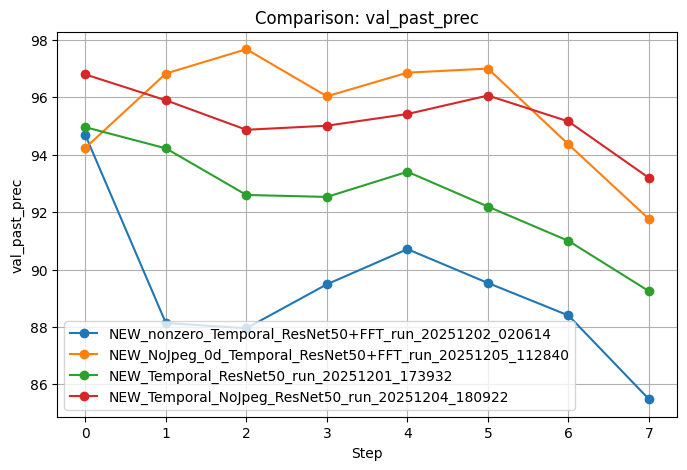

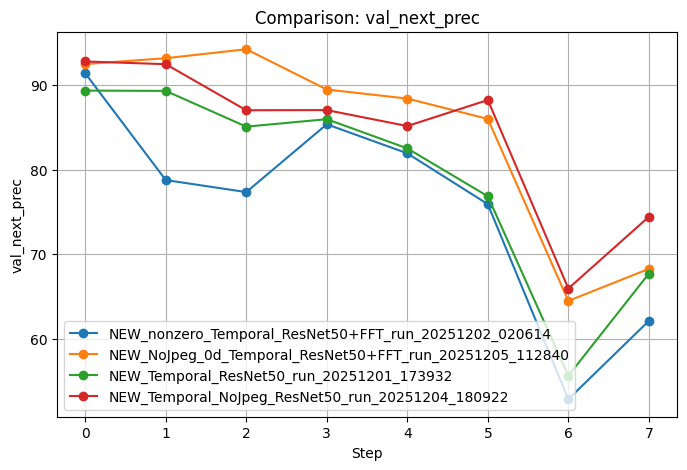

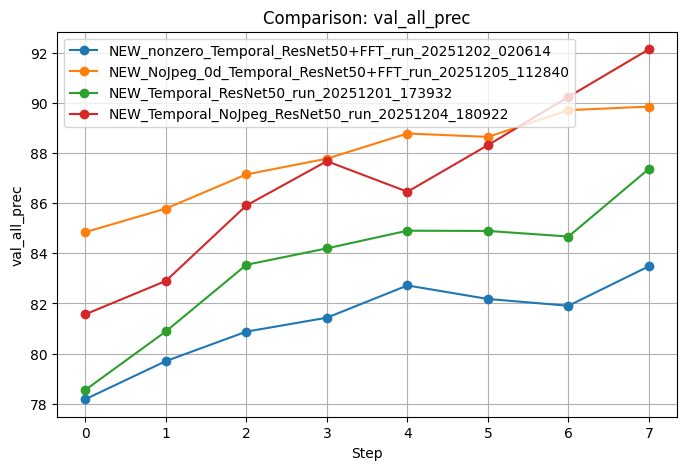

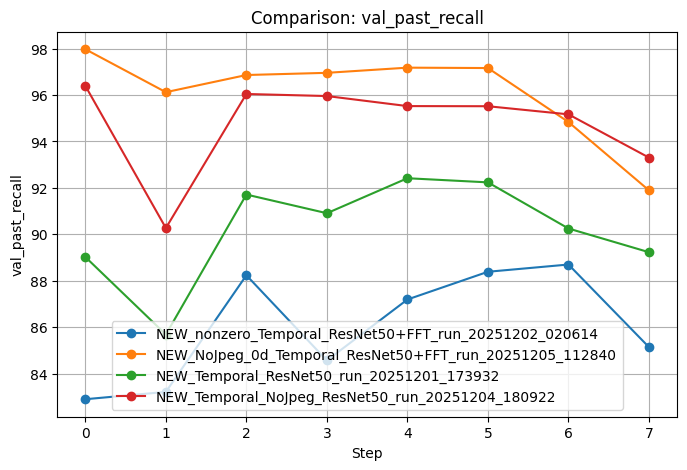

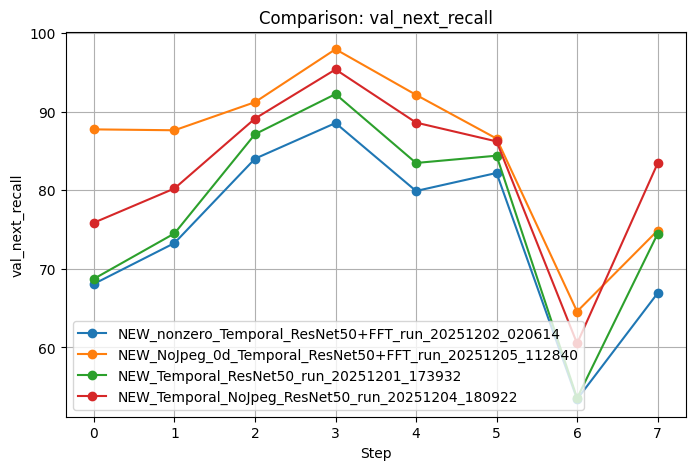

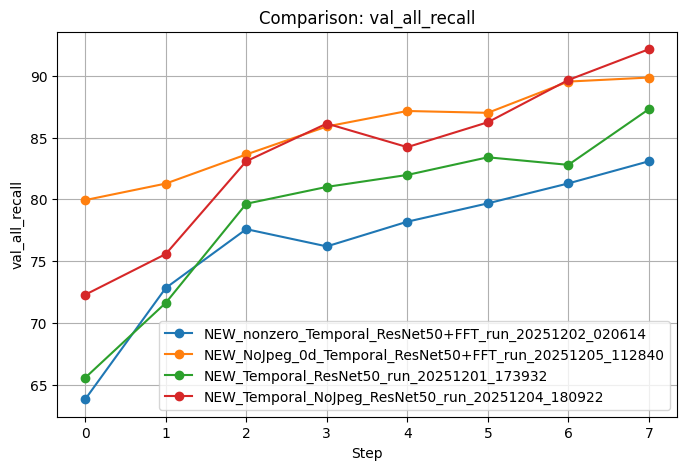

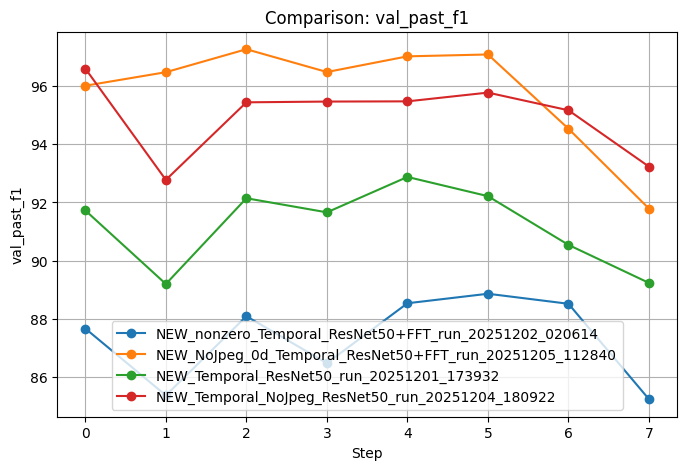

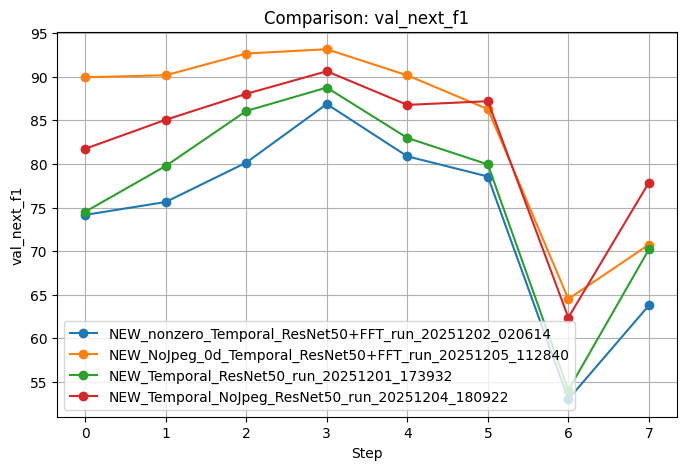

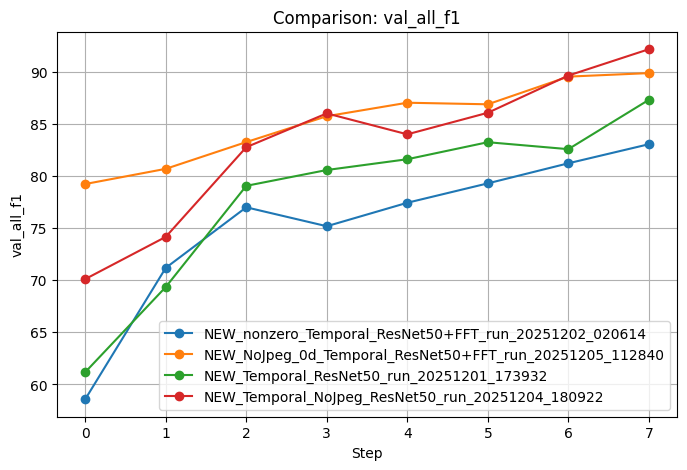

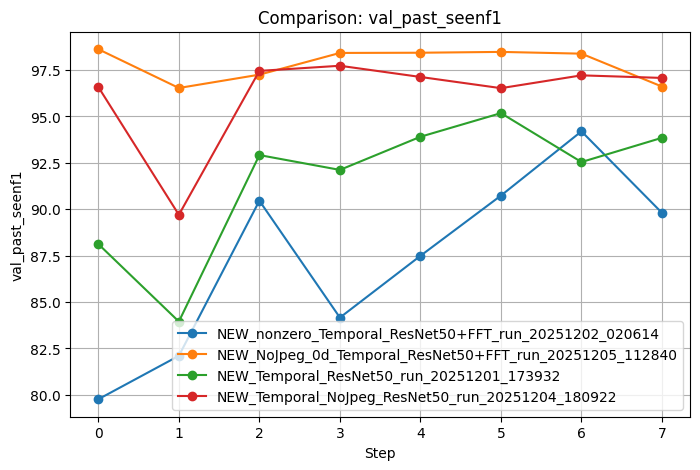

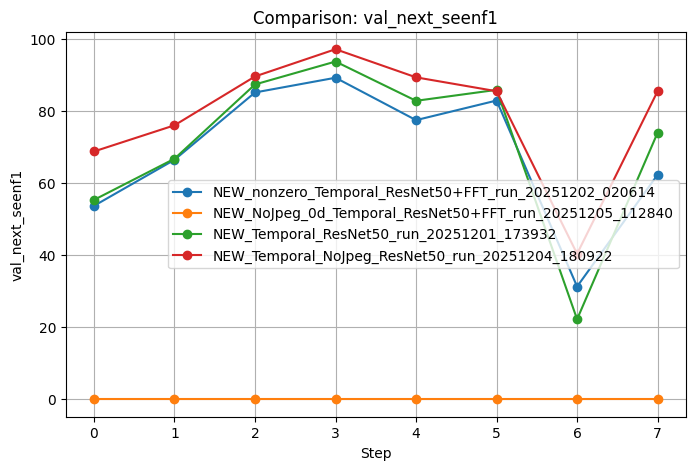

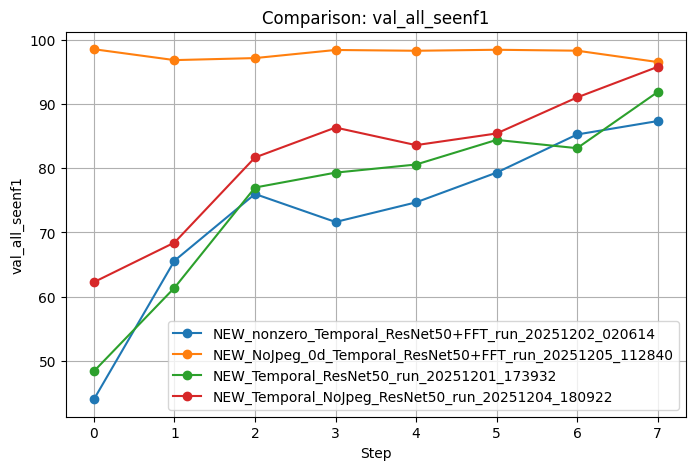

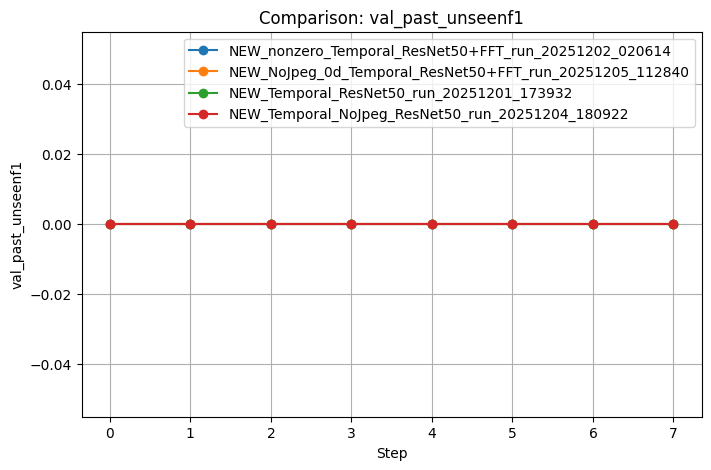

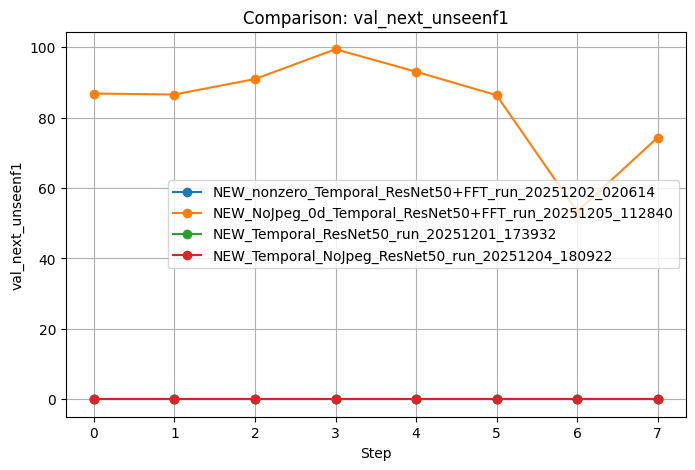

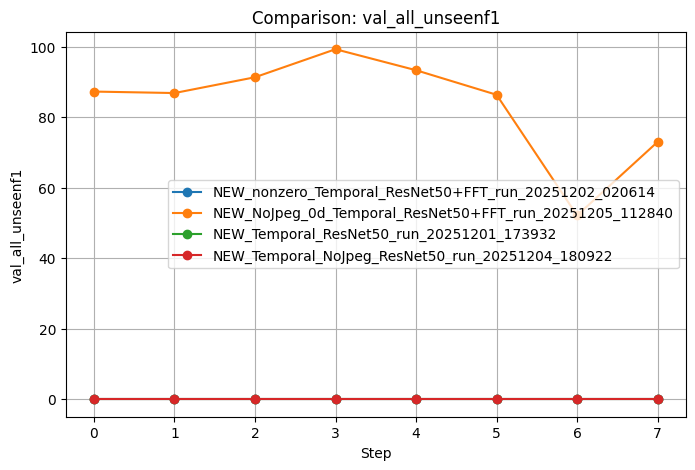

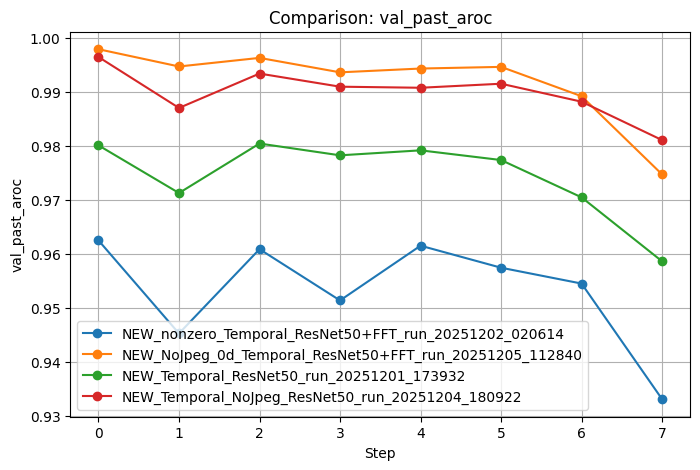

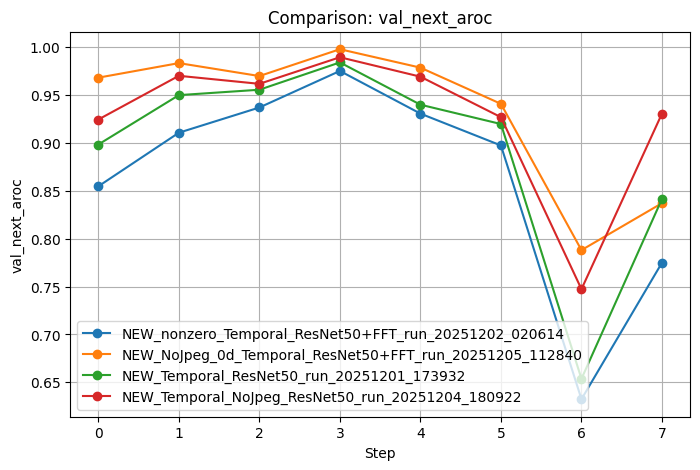

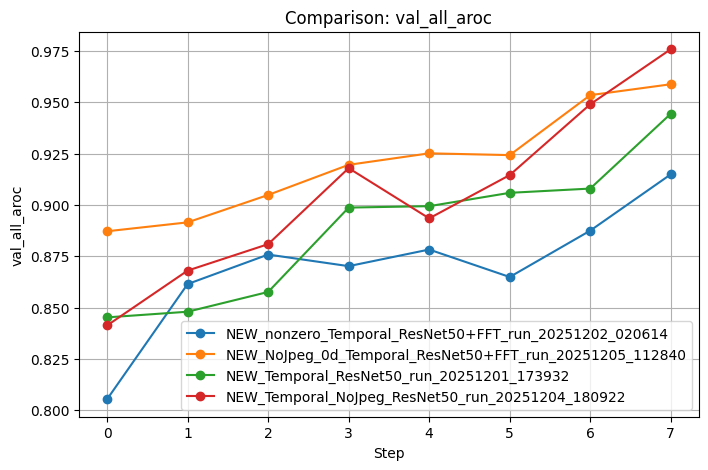

In [10]:
dfs = compare_logs(json_files)

In [16]:
no_jpeg_resnet.columns

Index(['model', 'run_timestamp', 'step', 'epoch', 'train_loss', 'train_acc',
       'val_past_acc', 'val_next_acc', 'val_all_acc', 'val_past_prec',
       'val_next_prec', 'val_all_prec', 'val_past_recall', 'val_next_recall',
       'val_all_recall', 'val_past_f1', 'val_next_f1', 'val_all_f1',
       'val_past_seenf1', 'val_next_seenf1', 'val_all_seenf1',
       'val_past_unseenf1', 'val_next_unseenf1', 'val_all_unseenf1',
       'val_past_aroc', 'val_next_aroc', 'val_all_aroc', 'epoch_minutes'],
      dtype='object')

All logs validated: identical steps & epochs.


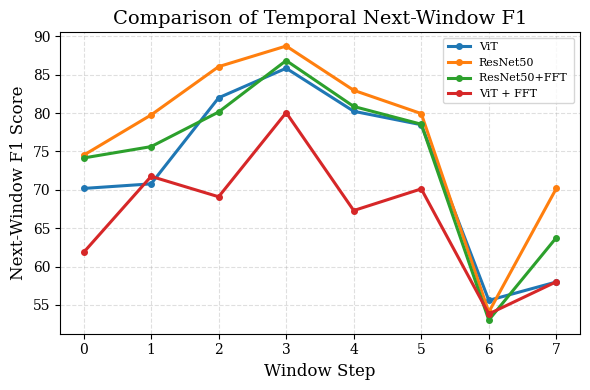

In [19]:
json_files = [
    "training/logs/full_metrics/NEW_Temporal_ViT_run_20251201_161225.json",
    "training/logs/full_metrics/NEW_Temporal_ResNet50_run_20251201_173932.json",
    "training/logs/full_metrics/NEW_nonzero_Temporal_ResNet50+FFT_run_20251202_020614.json",
    "training/logs/full_metrics/NEW_nonzero_Temporal_ViT_FFT_run_20251202_080626.json"

]

custom_names = {
    "NEW_Temporal_ViT_run_20251201_161225": "ViT",
    "NEW_Temporal_ResNet50_run_20251201_173932": "ResNet50",
    "NEW_nonzero_Temporal_ResNet50+FFT_run_20251202_020614": "ResNet50+FFT ",
    "NEW_nonzero_Temporal_ViT_FFT_run_20251202_080626": "ViT + FFT",
}


dfs = load_multiple_logs(json_files)
validate_logs(dfs)

plot_clean(dfs, custom_names=custom_names, save=True, metric="val_next_f1")